<a href="https://colab.research.google.com/github/bajatsira/description-of-life-cycle-processes/blob/main/%D0%98%D0%A35%D0%A6_81%D0%91_%D0%A1%D0%B5%D0%BC%D0%B8%D0%BD%D0%B0%D1%809_%D0%A7%D1%83%D0%BF%D0%B0%D0%BD%D0%BE%D0%B2%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install simpy

In [2]:
# -*- coding: utf-8 -*-
import random
import simpy
import matplotlib.pyplot as plt

%matplotlib inline

# --- БАЗОВЫЕ ПАРАМЕТРЫ  ---
RANDOM_SEED = 4210
PT_MEAN = 20.0         # среднее время изготовления детали на станке
PT_SIGMA = 4.0         # ср.квадр.отклонение времени изготовления детали
MTTF = 1000.0          # среднее время между поломками (Mean Time To Failure)
REPAIR_TIME = 20.0     # среднее время ремонта станка
NUM_MACHINES = 5       # количество станков
WEEKS = 2              # время моделирования в неделях
SIM_TIME = WEEKS * 7 * 24 * 60  # время моделирования в минутах

In [3]:
class Machine(object):
    def __init__(self, env, num, repairman):
        self.env = env
        self.parts_made = 0  # количество сделанных станком деталей
        self.broken = False  # станок не сломан!
        self.ID = num  # идентификатор станка
        self.repair_cnt = 0  # количество ремонтов станка
        self.totalFixDuration = 0  # общая длительность ремонтов
        self.totalFailureDuration = 0  # общая длительность простоев

        # запуск процессов работы и поломки станка
        self.workprocess = env.process(self.working(repairman))
        env.process(self.break_machine())

    def working(self, repairman):
        while True:
            # начало изготовления новой детали
            self.done_time = random.normalvariate(PT_MEAN, PT_SIGMA)
            while self.done_time:
                try:
                    # делаем деталь
                    self.start_work = self.env.now
                    yield self.env.timeout(self.done_time)
                    self.done_time = 0  # деталь доделана! =0
                except simpy.Interrupt:
                    self.broken = True  # станок сломан!
                    self.break_time = self.env.now  # время поломки станка
                    self.done_time -= self.env.now - self.start_work  # сколько осталось доделать

                    # приоритет 1 для ремонта
                    with repairman.request(priority=1) as req:
                        yield req  # будем ждать ремонтника
                        self.repair_cnt += 1  # начался новый ремонт
                        self.fix_time = self.env.now  # время начала ремонта
                        yield self.env.timeout(random.uniform(REPAIR_TIME-12, REPAIR_TIME+12))

                    self.broken = False   # станок восстановлен!
                    self.fix_duration = int(self.env.now - self.fix_time)
                    self.failure_duration = int(self.env.now - self.break_time)
                    self.totalFixDuration += self.fix_duration
                    self.totalFailureDuration += self.failure_duration

            self.parts_made += 1  # станок сделал деталь

    def break_machine(self):
        # поломка станка
        while True:
            yield self.env.timeout(random.expovariate(1.0/MTTF))
            # не надо ломать уже поломанный станок!!
            if not self.broken: self.workprocess.interrupt()

In [4]:
def work_sched(env, repairman, shift_mode='simultaneous'):
    """Управление сменами ремонтников. Добавлен режим shift_mode для Задания 3."""
    global men_at_work
    rep = [0,] * repairman.capacity

    if shift_mode == 'simultaneous':
        # --- ОРИГИНАЛЬНАЯ ЛОГИКА (Обе смены одновременно) ---
        day_start = 8*60
        for r in range(repairman.capacity):
            rep[r] = repairman.request(priority=-1)
            yield rep[r]
        men_at_work.append((0, env.now))

        while True:
            yield env.timeout(day_start)
            for r in range(repairman.capacity):
                repairman.release(rep[r])

            day_work = 8*60
            startworkperiod = env.now
            men_at_work.append((1, env.now))
            yield env.timeout(day_work)

            for r in range(repairman.capacity):
                rep[r] = repairman.request(priority=-1)
                yield rep[r]
            men_at_work.append((0, env.now))
            day_start = (24-8)*60 - (env.now - startworkperiod - day_work)

    elif shift_mode == 'sequential':
        # --- НОВАЯ ЛОГИКА (Задание 3: Ремонтники работают друг за другом) ---
        # Изначально оба отдыхают до 8:00
        for r in range(repairman.capacity):
            rep[r] = repairman.request(priority=-1)
            yield rep[r]

        while True:
            yield env.timeout(8 * 60) # Ждем до 8 утра

            # Смена 1 (8:00 - 16:00): Работает первый ремонтник
            repairman.release(rep[0])
            men_at_work.append((1, env.now)) # Кто-то на работе
            yield env.timeout(8 * 60)

            # Смена 2 (16:00 - 24:00): Работает второй ремонтник, первый уходит отдыхать
            rep[0] = repairman.request(priority=-1)
            yield rep[0]
            repairman.release(rep[1])
            yield env.timeout(8 * 60)

            # Ночь (00:00 - 08:00): Второй тоже уходит отдыхать, цех пуст
            rep[1] = repairman.request(priority=-1)
            yield rep[1]
            men_at_work.append((0, env.now)) # Никого нет на работе


def monitor_system(env, repairman):
    """Специальная функция для детального мониторинга (Задание 2)"""
    global rep_status_log
    while True:
        # Priority 1 = Ремонт, Priority -1 = Отдых
        repairing = sum(1 for req in repairman.users if req.priority == 1)
        off = sum(1 for req in repairman.users if req.priority == -1)
        idle = repairman.capacity - repairing - off
        rep_status_log.append((env.now, idle, repairing, off))
        yield env.timeout(10.0)

=== ЗАПУСК 1: ОДНОВРЕМЕННАЯ СМЕНА (БАЗОВАЯ) ===


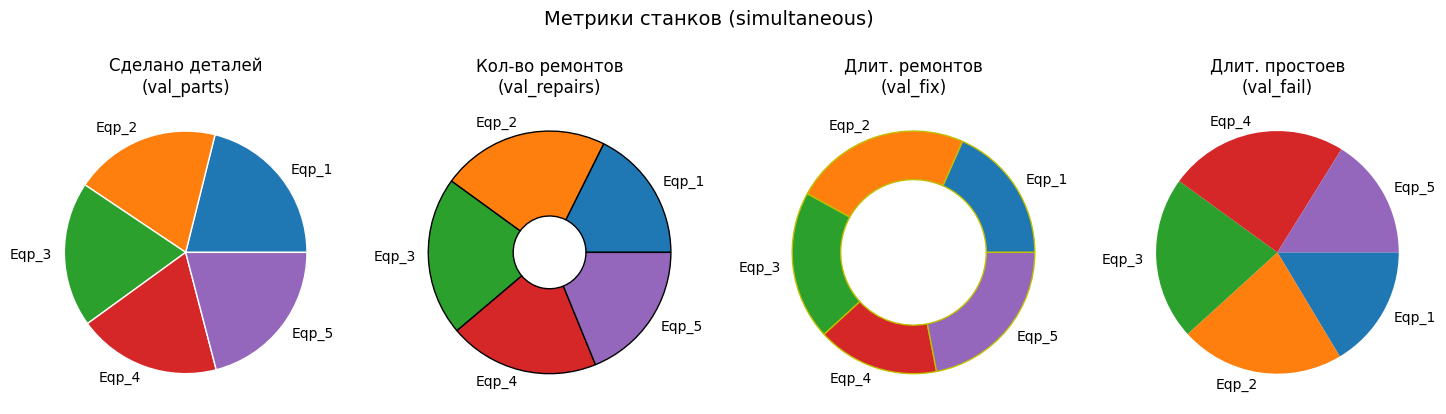

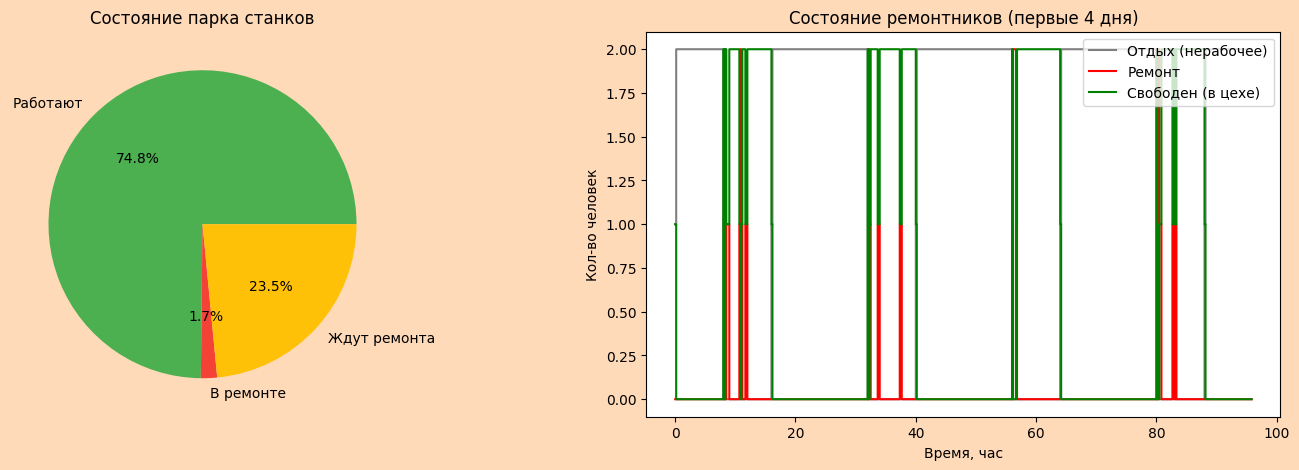


=== ЗАПУСК 2: ПОСЛЕДОВАТЕЛЬНАЯ СМЕНА (ЗАДАНИЕ 3) ===


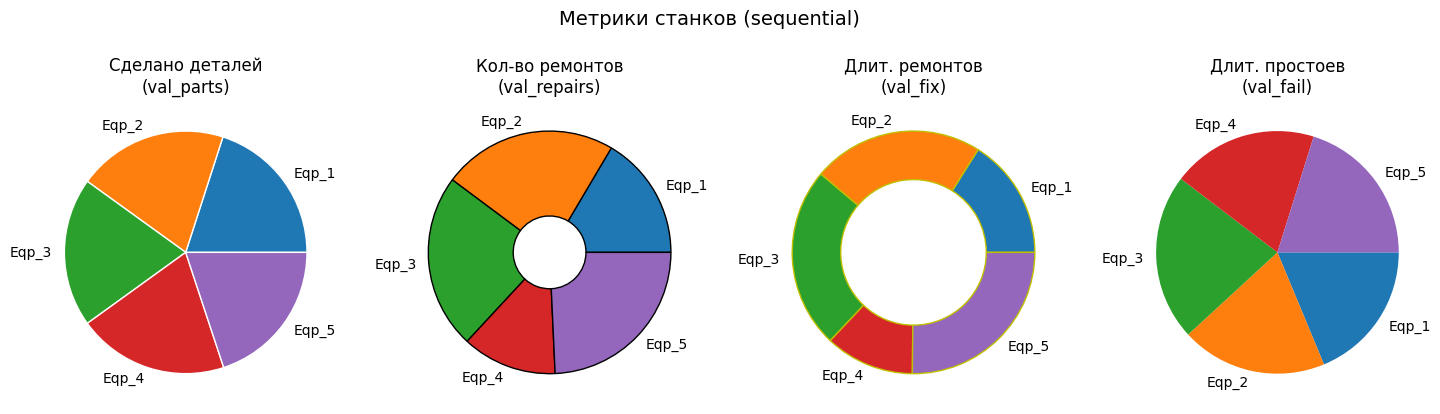

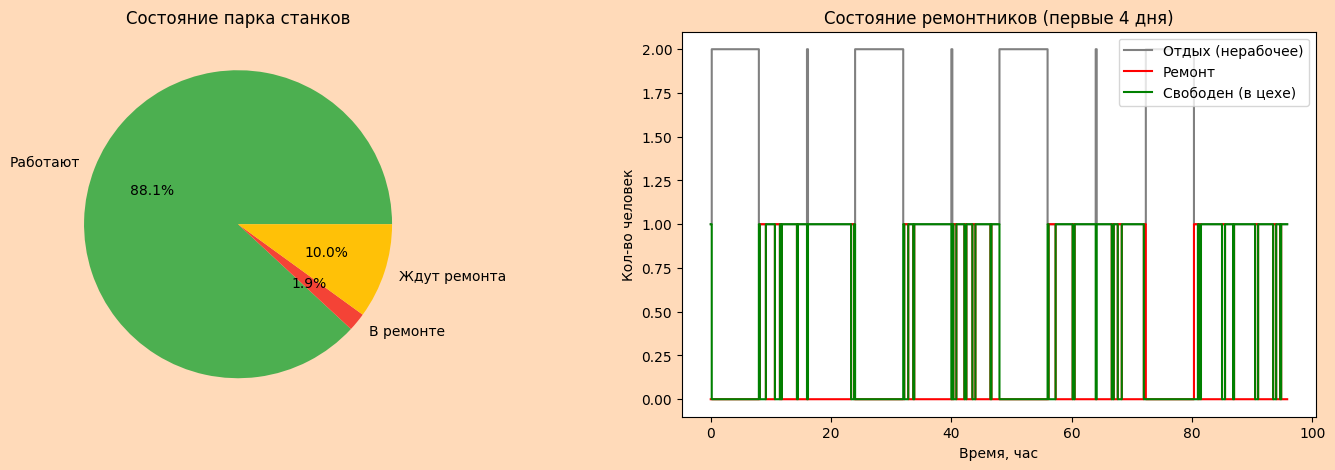

In [5]:
def run_and_plot(shift_mode):
    global men_at_work, rep_status_log
    men_at_work = []
    rep_status_log = []

    random.seed(RANDOM_SEED)
    env = simpy.Environment()
    repairmen = simpy.PriorityResource(env, capacity=2)
    machines = [Machine(env, i+1, repairmen) for i in range(NUM_MACHINES)]

    env.process(work_sched(env, repairmen, shift_mode))
    env.process(monitor_system(env, repairmen))

    env.run(until=SIM_TIME)

    # --- ЗАДАНИЕ 1: ИСПРАВЛЕНИЕ ДИАГРАММ ---
    lab = [f'Eqp_{m.ID}' for m in machines]
    val_parts = [m.parts_made for m in machines]
    val_repairs = [m.repair_cnt for m in machines]
    val_fix = [m.totalFixDuration for m in machines]
    val_fail = [m.totalFailureDuration for m in machines]

    fig, bx = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle(f'Метрики станков ({shift_mode})', fontsize=14)

    bx[0].set_title('Сделано деталей\n(val_parts)')
    bx[0].pie(val_parts, labels=lab, wedgeprops=dict(width=1, edgecolor='w'))

    bx[1].set_title('Кол-во ремонтов\n(val_repairs)')
    bx[1].pie(val_repairs, labels=lab, wedgeprops=dict(width=0.7, edgecolor='black'))

    bx[2].set_title('Длит. ремонтов\n(val_fix)')
    bx[2].pie(val_fix, labels=lab, wedgeprops=dict(width=0.4, edgecolor='y'))

    bx[3].set_title('Длит. простоев\n(val_fail)')
    bx[3].pie(val_fail, labels=lab, counterclock=False)
    plt.show()

    # --- ЗАДАНИЕ 2: НОВЫЕ ДИАГРАММЫ ---
    fig2, ax2 = plt.subplots(1, 2, figsize=(18, 5))
    fig2.set_facecolor('peachpuff')

    # 2.1 Круговая диаграмма состояния станков (Суммарно по цеху)
    total_downtime = sum(val_fail)
    total_repair = sum(val_fix)
    total_wait = total_downtime - total_repair
    total_work = (NUM_MACHINES * SIM_TIME) - total_downtime

    ax2[0].set_title('Состояние парка станков')
    ax2[0].pie([total_work, total_repair, total_wait],
               labels=['Работают', 'В ремонте', 'Ждут ремонта'],
               autopct='%1.1f%%', colors=['#4CAF50', '#F44336', '#FFC107'])

    # 2.2 Ступенчатый график ремонтников
    times = [p[0]/60 for p in rep_status_log] # Часы
    repairing = [p[2] for p in rep_status_log]
    idle = [p[1] for p in rep_status_log]
    off = [p[3] for p in rep_status_log]

    limit = (4 * 24 * 60) // 10 # Показываем первые 4 дня для наглядности
    ax2[1].step(times[:limit], off[:limit], label='Отдых (нерабочее)', where='post', color='gray')
    ax2[1].step(times[:limit], repairing[:limit], label='Ремонт', where='post', color='red')
    ax2[1].step(times[:limit], idle[:limit], label='Свободен (в цехе)', where='post', color='green')
    ax2[1].set_title('Состояние ремонтников (первые 4 дня)')
    ax2[1].set_xlabel('Время, час')
    ax2[1].set_ylabel('Кол-во человек')
    ax2[1].legend(loc='upper right')
    plt.show()

    return machines

print("=== ЗАПУСК 1: ОДНОВРЕМЕННАЯ СМЕНА (БАЗОВАЯ) ===")
mach_simul = run_and_plot('simultaneous')

print("\n=== ЗАПУСК 2: ПОСЛЕДОВАТЕЛЬНАЯ СМЕНА (ЗАДАНИЕ 3) ===")
mach_seq = run_and_plot('sequential')

In [6]:
def print_comparison(mach_simul, mach_seq):
    print("=== СРАВНЕНИЕ КОНФИГУРАЦИЙ (ЗАДАНИЕ 3) ===")

    def get_stats(machines):
        parts = sum(m.parts_made for m in machines)
        downtime = sum(m.totalFailureDuration for m in machines)
        rep_time = sum(m.totalFixDuration for m in machines)
        return parts, downtime, rep_time

    p_sim, d_sim, r_sim = get_stats(mach_simul)
    p_seq, d_seq, r_seq = get_stats(mach_seq)

    print(f"{'Метрика':<25} | {'Одновременная смена':<20} | {'Последовательная смена':<20} | {'Изменение'}")
    print("-" * 85)
    print(f"{'Изготовлено деталей':<25} | {p_sim:<20} | {p_seq:<20} | {((p_seq-p_sim)/p_sim)*100:+.1f}%")
    print(f"{'Общие простои (мин)':<25} | {d_sim:<20} | {d_seq:<20} | {((d_seq-d_sim)/d_sim)*100:+.1f}%")
    print(f"{'Чистое время ремонта':<25} | {r_sim:<20} | {r_seq:<20} | {((r_seq-r_sim)/r_sim)*100:+.1f}%")

print_comparison(mach_simul, mach_seq)

=== СРАВНЕНИЕ КОНФИГУРАЦИЙ (ЗАДАНИЕ 3) ===
Метрика                   | Одновременная смена  | Последовательная смена | Изменение
-------------------------------------------------------------------------------------
Изготовлено деталей       | 3734                 | 4427                 | +18.6%
Общие простои (мин)       | 25377                | 12005                | -52.7%
Чистое время ремонта      | 1713                 | 1936                 | +13.0%
